# Lab02: House Prices — Advanced Regression (PyTorch + CRISP-DM)

Cuộc thi Kaggle: dự báo `SalePrice` (RMSLE). Toàn bộ mô hình bằng PyTorch.
Nhật ký thí nghiệm: `experiments/model_log.md`.


## 0. Thiết lập & helpers (GĐ0)


In [1]:
# --- Thư viện chuẩn: mỗi dòng 1 lệnh import ---
import csv  # ghi thêm dòng vào runs.csv (dùng trong save_run)
import json  # lưu cấu hình thí nghiệm dạng JSON
import random  # gieo seed cho hàm ngẫu nhiên của python
from pathlib import Path  # thao tác đường dẫn gọn, chạy được mọi OS
import numpy as np  # tính toán số (trung bình, độ lệch chuẩn CV)
import pandas as pd  # đọc CSV và EDA
import torch  # xây + huấn luyện mọi mô hình (chỉ dùng CPU)
import matplotlib.pyplot as plt  # vẽ đường học, residual
import seaborn as sns  # vẽ biểu đồ thống kê đẹp hơn
from sklearn.model_selection import KFold  # chia K-fold CV

# --- Seed chung: giữ mỗi lần chạy cho kết quả giống nhau ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Đường dẫn: tự động nhận cả khi mở ở root hay trong Lab02 ---
ROOT = (
    Path("data") if Path("data").exists() else Path("Lab02/data")
)  # thư mục CSV Kaggle
EXP = (
    Path("experiments") if Path("experiments").exists() else Path("Lab02/experiments")
)  # thư mục log
print(torch.__version__, "| train/test sẽ đọc ở Part 1")

2.14.0+cpu | train/test sẽ đọc ở Part 1


In [2]:
"""Ham dung chung cho moi thi nghiem (M0-M7)."""


def make_exp_id(model, tag):
    """Ghép ID duy nhất cho thí nghiệm, vd: M5_mlp_d3_w128_do02."""
    return f"{model}_{tag}"


def rmsle(y_true_log, y_pred_log):
    """Tính RMSLE trực tiếp trên thang log (khớp metric Kaggle)."""
    return float(
        np.sqrt(np.mean((np.asarray(y_pred_log) - np.asarray(y_true_log)) ** 2))
    )


def save_run(exp_id, model, params, fold_scores, note="", decision=""):
    """Lưu 1 thí nghiệm vào 3 nơi: JSON cấu hình, runs.csv, model_log.md."""
    if EXP.joinpath(
        "runs.csv"
    ).exists():  # chạy lại notebook: có log rồi thì đừng thêm nữa
        old = list(csv.DictReader(open(EXP / "runs.csv", encoding="utf-8")))
        hit = [r for r in old if r["exp_id"] == exp_id]
        if hit:
            print(
                f"[{exp_id}] đã log: CV-RMSLE = {hit[0]['cv_mean']} ± {hit[0]['cv_std']}"
            )
            return float(hit[0]["cv_mean"])
    (EXP / "configs").mkdir(parents=True, exist_ok=True)  # tạo thư mục nếu chưa có
    (EXP / "configs" / f"{exp_id}.json").write_text(
        json.dumps(  # lưu cấu hình để tái lập
            {
                "exp_id": exp_id,
                "model": model,
                "params": params,
                "fold_scores": fold_scores,
            },
            indent=1,
        )
    )
    m, s = (
        float(np.mean(fold_scores)),
        float(np.std(fold_scores)),
    )  # trung bình ± lệch chuẩn CV
    row = {
        "exp_id": exp_id,
        "model": model,
        "params": json.dumps(params),
        "cv_mean": round(m, 5),
        "cv_std": round(s, 5),
        "fold_scores": str([round(float(x), 5) for x in fold_scores]),
        "note": note,
        "decision": decision,
    }
    with open(
        EXP / "runs.csv", "a", newline="", encoding="utf-8"
    ) as f:  # ghi thêm vào bảng máy đọc
        w = csv.DictWriter(f, fieldnames=list(row))
        w.writerow(row)
    with open(
        EXP / "model_log.md", "a", encoding="utf-8"
    ) as f:  # ghi thêm vào nhật ký người đọc
        f.write(
            f"| {exp_id} | {model} | `{row['params']}` | {row['cv_mean']} ± {row['cv_std']} | {note} | {decision} |\n"
        )
    print(f"[{exp_id}] CV-RMSLE = {m:.5f} ± {s:.5f} -> {decision}")


# --- Tự kiểm: RMSLE của dự đoán lệch nhẹ phải ~0.1 ---

## 1. Business Understanding — Xác định bài toán (GĐ1)
*(phân tích chi tiết ở GĐ1)*


### 1.1. Mục tiêu (Business Understanding)
- **Bài toán:** hồi quy có giám sát — dự báo giá bán `SalePrice` (USD) của 1459 căn nhà ở Ames, Iowa trong tập test Kaggle.
- **Bối cảnh thực tế (paper De Cock):** thay mô hình định giá thủ công của Văn phòng Thẩm định Ames bằng mô hình học từ ~80 biến mô tả nhà.
- **Metric chấm điểm:** RMSLE — căn bậc hai sai số bình phương trên thang log: `sqrt(mean((log1p(pred)-log1p(true))^2))`.
  Hệ quả: phạt sai số *tương đối* (nhà rẻ sai 10k nặng hơn nhà đắt sai 10k), nên mọi huấn luyện/đánh giá đều làm trên thang log.
- **Dữ liệu:** train 1460 dòng (có nhãn) + test 1459 dòng; 79 biến giải thích: 23 nominal, 23 ordinal, 14 discrete, 20 continuous.
- **Tiêu chí thành công:** CV-RMSLE ổn định và giảm dần qua các thí nghiệm; tham chiếu paper (Neighborhood+TotalSF ≈ R² 80%); điểm public LB khi nộp Kaggle.
- **Ràng buộc:** toàn bộ mô hình bằng PyTorch (sklearn chỉ chia fold + tiền xử lý); đủ 6 bước CRISP-DM; có nhật ký thí nghiệm.


## 2. Data Understanding — EDA (GĐ1)
*(phân phối giá, missing, tương quan, outlier — GĐ1)*


In [3]:
# --- Đọc dữ liệu, xem kích thước và phân phối biến mục tiêu ---
train = pd.read_csv(ROOT / "train.csv")  # tập train: có cột SalePrice để học
test = pd.read_csv(ROOT / "test.csv")  # tập test: không nhãn, cần dự báo để nộp
print("train:", train.shape, "| test:", test.shape)  # kiểm tra đúng 1460/1459 dòng
y = train["SalePrice"]  # biến mục tiêu (USD)
print(
    y.describe()[["count", "mean", "std", "min", "50%", "max"]].round(1)
)  # thống kê mô tả nhanh
print(
    "skew giá gốc:",
    round(float(y.skew()), 3),
    "| skew sau log1p:",
    round(float(np.log1p(y).skew()), 3),
)

train: (1460, 81) | test: (1459, 80)
count      1460.0
mean     180921.2
std       79442.5
min       34900.0
50%      163000.0
max      755000.0
Name: SalePrice, dtype: float64
skew giá gốc: 1.883 | skew sau log1p: 0.121


In [4]:
# --- Đếm ô trống (missing) theo từng cột ---
miss = train.isna().sum()  # đếm số ô trống mỗi cột
miss = miss[miss > 0].sort_values(ascending=False)  # chỉ giữ cột có thiếu, xếp giảm dần
print(f"Co {len(miss)} cột thiếu / {train.shape[1]} cot")
print(
    (
        miss.to_frame("n_thiếu").assign(
            ty_le=lambda d: (d["n_thiếu"] / len(train)).round(3)
        )
    ).head(20)
)

Co 19 cột thiếu / 81 cot
              n_thiếu  ty_le
PoolQC           1453  0.995
MiscFeature      1406  0.963
Alley            1369  0.938
Fence            1179  0.808
MasVnrType        872  0.597
FireplaceQu       690  0.473
LotFrontage       259  0.177
GarageType         81  0.055
GarageYrBlt        81  0.055
GarageFinish       81  0.055
GarageQual         81  0.055
GarageCond         81  0.055
BsmtExposure       38  0.026
BsmtFinType2       38  0.026
BsmtQual           37  0.025
BsmtCond           37  0.025
BsmtFinType1       37  0.025
MasVnrArea          8  0.005
Electrical          1  0.001


In [5]:
# --- Tương quan biến số với giá + độ phong phú biến phân loại + outlier ---
num = train.select_dtypes(include=[np.number]).drop(
    columns=["Id", "SalePrice"]
)  # chỉ biến số
corr = num.corrwith(np.log1p(y)).sort_values(
    ascending=False
)  # tương quan với log-giá (khớp metric)
print("Top tương quan dương:")
print(corr.head(8).round(3))
print("Top tương quan âm:")
print(corr.tail(3).round(3))
cat = train.select_dtypes(exclude=[np.number]).columns  # các cột phân loại (chuỗi)
print("Số cột phân loại:", len(cat), "| nhiều mức nhất:")
print(train[cat].nunique().sort_values(ascending=False).head(8))  # đếm số mức mỗi cột
out = train[train["GrLivArea"] > 4000][
    ["GrLivArea", "SalePrice"]
]  # outlier paper đã cảnh báo
print(f"Số nhà GrLivArea>4000: {len(out)}")
print(out.to_string())

Top tương quan dương:
OverallQual    0.817
GrLivArea      0.701
GarageCars     0.681
GarageArea     0.651
TotalBsmtSF    0.612
1stFlrSF       0.597
FullBath       0.595
YearBuilt      0.587
dtype: float64
Top tương quan âm:
MSSubClass      -0.074
KitchenAbvGr    -0.148
EnclosedPorch   -0.149
dtype: float64
Số cột phân loại: 43 | nhiều mức nhất:
Neighborhood    25
Exterior2nd     16
Exterior1st     15
Condition1       9
SaleType         9
HouseStyle       8
RoofMatl         8
Condition2       8
dtype: int64
Số nhà GrLivArea>4000: 4
      GrLivArea  SalePrice
523        4676     184750
691        4316     755000
1182       4476     745000
1298       5642     160000


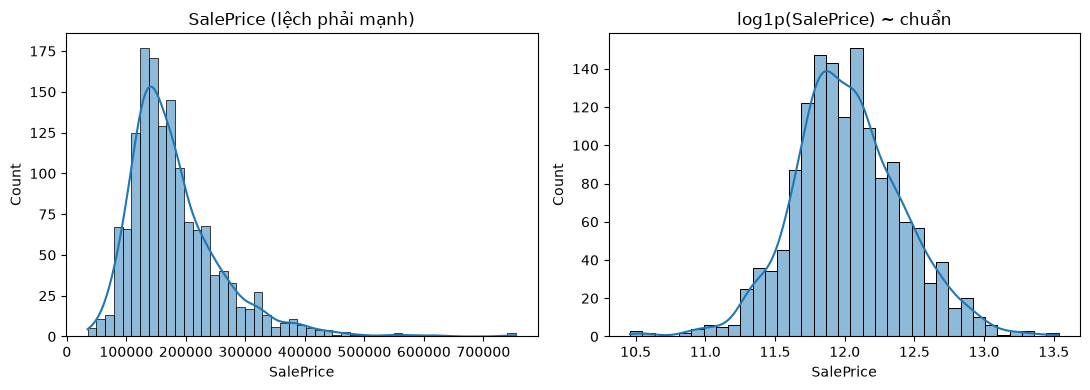

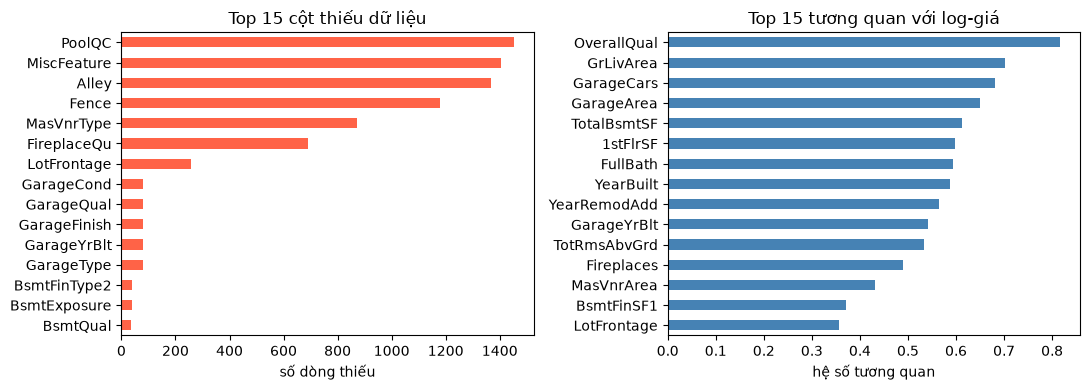

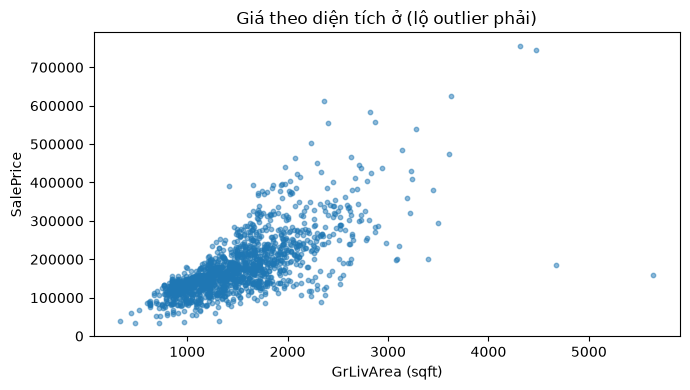

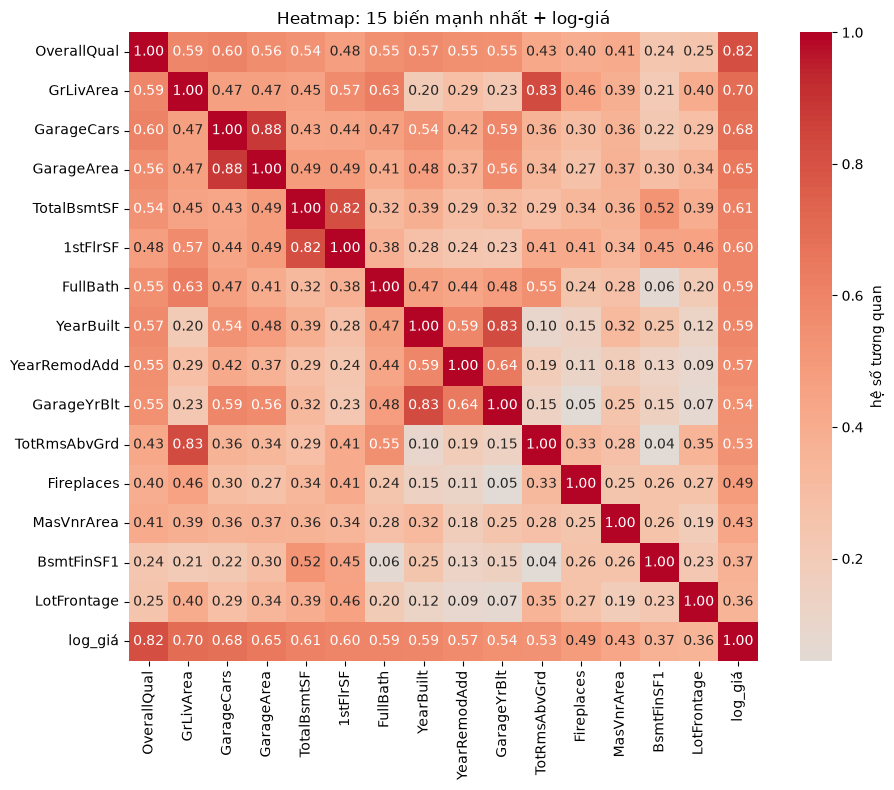

Đã lưu ảnh vào experiments\figures


In [6]:
# --- Vẽ 4 biểu đồ EDA, vừa hiển thị vừa lưu cho báo cáo ---
FIG = EXP / "figures"
FIG.mkdir(parents=True, exist_ok=True)  # thư mục chứa ảnh (không commit)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))  # 2 ô cạnh nhau: giá gốc vs log-giá
sns.histplot(y, kde=True, ax=ax[0])
ax[0].set_title("SalePrice (lệch phải mạnh)")  # đuôi dài bên phải
sns.histplot(np.log1p(y), kde=True, ax=ax[1])
ax[1].set_title("log1p(SalePrice) ~ chuẩn")  # đối xứng hơn
fig.tight_layout()
fig.savefig(FIG / "eda_gia.png", dpi=100)
plt.show()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
miss.head(15).sort_values().plot.barh(
    ax=ax[0], color="tomato"
)  # 15 cột thiếu nhiều nhất
ax[0].set_title("Top 15 cột thiếu dữ liệu")
ax[0].set_xlabel("số dòng thiếu")
corr.head(15).sort_values().plot.barh(
    ax=ax[1], color="steelblue"
)  # 15 biến số liên quan nhất
ax[1].set_title("Top 15 tương quan với log-giá")
ax[1].set_xlabel("hệ số tương quan")
fig.tight_layout()
fig.savefig(FIG / "eda_missing_corr.png", dpi=100)
plt.show()
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(train["GrLivArea"], y, s=10, alpha=0.5)  # mỗi chấm là 1 căn nhà
ax.set_xlabel("GrLivArea (sqft)")
ax.set_ylabel("SalePrice")
ax.set_title("Giá theo diện tích ở (lộ outlier phải)")
fig.tight_layout()
fig.savefig(FIG / "eda_outlier.png", dpi=100)
plt.show()
# --- Heatmap: nhìn 1 ảnh thấy ngay cụm biến nào đi cùng nhau ---
top15 = corr.head(15).index.tolist()  # 15 biến số liên quan nhất toi gia
sub = train[top15].copy()
sub["log_giá"] = np.log1p(y)  # thêm cột log-giá để đối chiếu
C = sub.corr()  # ma trận tương quan đôi một
fig, ax = plt.subplots(figsize=(10, 8))  # ô vuông để dễ đọc
sns.heatmap(
    C,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,  # số trên từng ô, đỏ=xanh theo dấu
    cbar_kws={"label": "hệ số tương quan"},
    ax=ax,
)
ax.set_title(
    "Heatmap: 15 biến mạnh nhất + log-giá"
)  # cụm Garage/DT nằm sát nhau = đa cộng tuyến
fig.tight_layout()
fig.savefig(FIG / "eda_corr_heatmap.png", dpi=100)
plt.show()
print("Đã lưu ảnh vào", FIG)

### 2.1. Nhận xét EDA

- **Giá lệch phải mạnh:** skew 1.883, trung vị 163k < trung bình 181k; sau `log1p` skew còn 0.121 (~chuẩn) → quyết định làm việc trên thang log là đúng, khớp metric RMSLE.
- **Thiếu dữ liệu 19/81 cột, đều có ý nghĩa:** PoolQC (99.5%), MiscFeature (96%), Alley (94%), Fence (81%) thiếu = *không có* hạng mục đó → điền `'Missing'` thay vì xóa. Nhóm garage (5.5%) và basement (~2.5%) thiếu đồng loạt theo cụm → cùng cách xử lý. Chỉ MasVnrArea (8) và Electrical (1) là thiếu lẻ.
- **Biến số đắt giá nhất:** OverallQual (0.817), GrLivArea (0.701), GarageCars (0.681), GarageArea (0.651), TotalBsmtSF (0.612) — đúng các biến paper nhấn mạnh. Tương quan âm nhẹ: EnclosedPorch (-0.149), KitchenAbvGr (-0.148) — bếp/hiên phụ nhiều đôi khi đi với nhà cũ nhỏ.
- **Biến phân loại:** 43 cột; Neighborhood nhiều mức nhất (25 mức trong train) → one-hot phình chiều nhưng cần thiết (hiệu ứng vị trí mạnh theo paper).
- **Outlier:** 4 căn GrLivArea > 4000 (paper báo 5 trên toàn bộ 2930 dòng; tập train Kaggle có 4), gồm 2 căn to nhưng rẻ bất thường (dòng 523: 4676 sqft giá 184750; dòng 1298: 5642 sqft giá 160000) → loại khỏi train theo khuyến nghị.
- **Nhìn heatmap:** cụm Garage (Cars/Area), cụm diện tích (GrLivArea/TotalBsmtSF/1stFlrSF) và OverallQual dính chùm đỏ → đa cộng tuyến rõ, báo trước GĐ2 phải dùng regularization.


3 khu rẻ nhất:
Neighborhood
MeadowV     88000.0
IDOTRR     103000.0
BrDale     106000.0
3 khu đắt nhất:
Neighborhood
StoneBr    278000.0
NoRidge    301500.0
NridgHt    315000.0


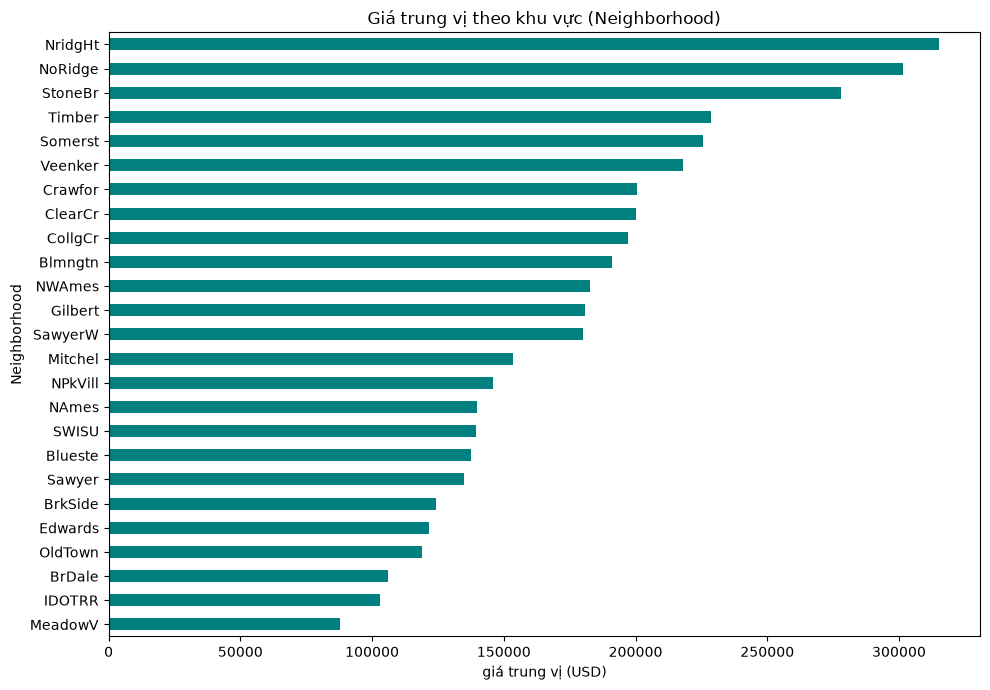

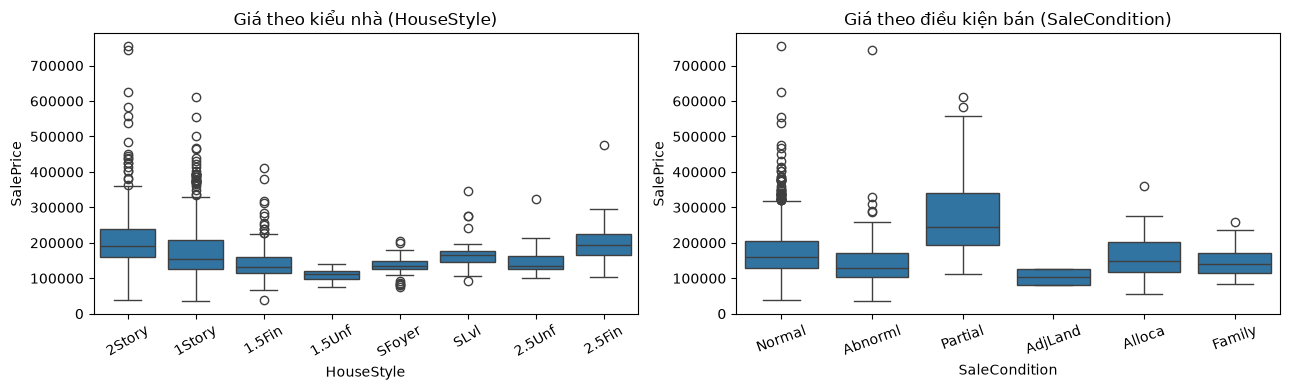

In [7]:
# --- E5: giá theo khu vực và loại hình giao dịch ---
med_nb = (
    train.groupby("Neighborhood")["SalePrice"].median().sort_values()
)  # trung vị từng khu, xếp tăng dần
print("3 khu rẻ nhất:")
print(med_nb.head(3).round(0).to_string())  # in số thật để đối chiếu
print("3 khu đắt nhất:")
print(med_nb.tail(3).round(0).to_string())
fig, ax = plt.subplots(figsize=(10, 7))  # đủ cao để đọc 25 tên khu
med_nb.plot.barh(ax=ax, color="teal")  # cột ngang xếp theo giá
ax.set_title("Giá trung vị theo khu vực (Neighborhood)")  # tiêu đề tiếng Việt có dấu
ax.set_xlabel("giá trung vị (USD)")
fig.tight_layout()
fig.savefig(FIG / "eda_neighborhood.png", dpi=100)
plt.show()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))  # 2 hộp cạnh nhau
sns.boxplot(data=train, x="HouseStyle", y="SalePrice", ax=ax[0])  # giá theo kiểu nhà
ax[0].set_title("Giá theo kiểu nhà (HouseStyle)")
ax[0].tick_params(axis="x", rotation=30)  # xoay nhãn cho đỡ đè
sns.boxplot(
    data=train, x="SaleCondition", y="SalePrice", ax=ax[1]
)  # giá theo điều kiện bán
ax[1].set_title("Giá theo điều kiện bán (SaleCondition)")
ax[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIG / "eda_cat_box.png", dpi=100)
plt.show()

6 cột lệch nhất + skew trước/sau log1p:
MiscVal: 24.48 -> 5.17
PoolArea: 14.83 -> 14.36
LotArea: 12.21 -> -0.14
3SsnPorch: 10.30 -> 7.73
LowQualFinSF: 9.01 -> 7.46
KitchenAbvGr: 4.49 -> 3.87


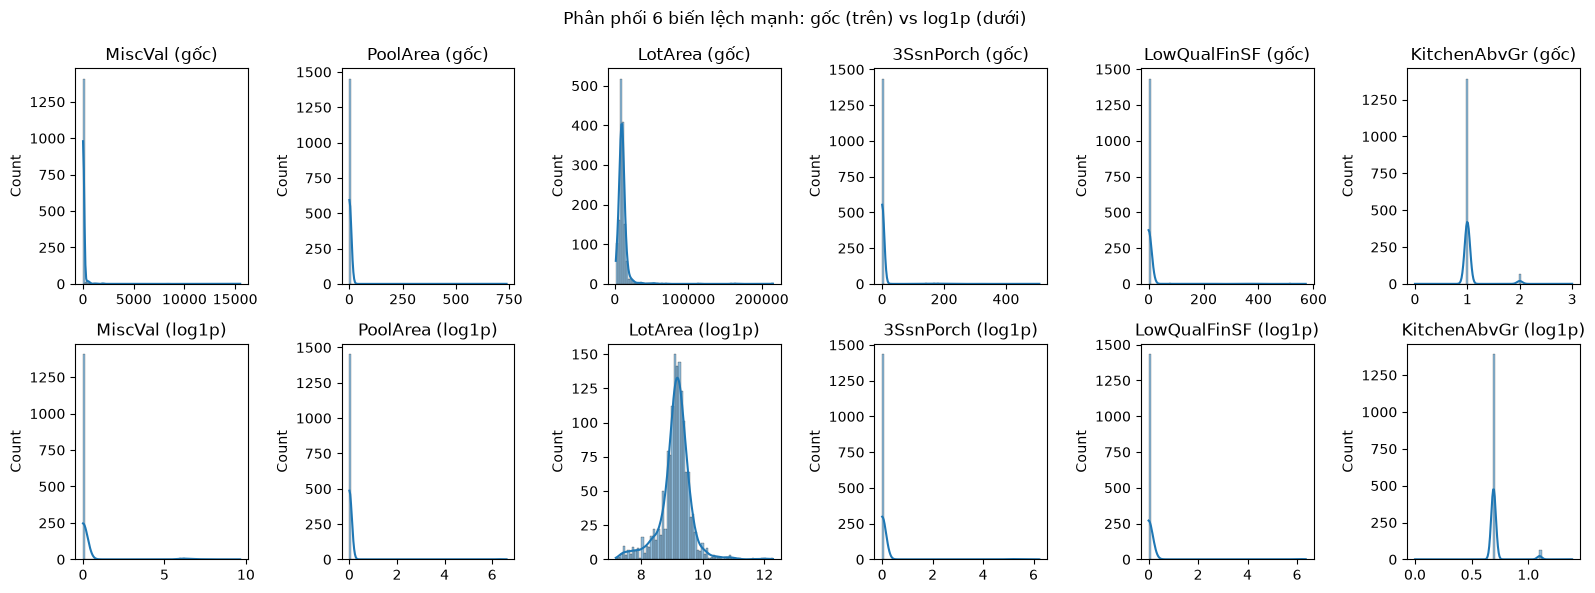

In [8]:
# --- E6: biến số lệch mạnh trước/sau log (minh chứng cho bước log1p) ---
sk = num.skew().sort_values(
    ascending=False
)  # dùng khung số đã có ở EDA, xếp theo độ lệch
top_skew = sk[sk > 1.0].head(6).index.tolist()  # lấy 6 cột lệch nhất (skew > 1)
print("6 cột lệch nhất + skew trước/sau log1p:")
for c in top_skew:
    v = train[c].dropna().to_numpy(dtype=float)  # bỏ trống rồi tính
    print(
        f"{c}: {pd.Series(v).skew():.2f} -> {pd.Series(np.log1p(np.clip(v, 0, None))).skew():.2f}"
    )
fig, axes = plt.subplots(2, 6, figsize=(16, 6))  # hàng trên: gốc, hàng dưới: sau log
for j, c in enumerate(top_skew):
    v = train[c].dropna().to_numpy(dtype=float)
    sns.histplot(v, kde=True, ax=axes[0, j])
    axes[0, j].set_title(f"{c} (gốc)")  # đuôi dài
    sns.histplot(np.log1p(np.clip(v, 0, None)), kde=True, ax=axes[1, j])
    axes[1, j].set_title(f"{c} (log1p)")  # gọn lại
fig.suptitle(
    "Phân phối 6 biến lệch mạnh: gốc (trên) vs log1p (dưới)"
)  # tiêu đề chung cả hình
fig.tight_layout()
fig.savefig(FIG / "eda_skew.png", dpi=100)
plt.show()

Trung vị thập niên 2000+ so với trước 1950:
226500.0 vs 128700.0


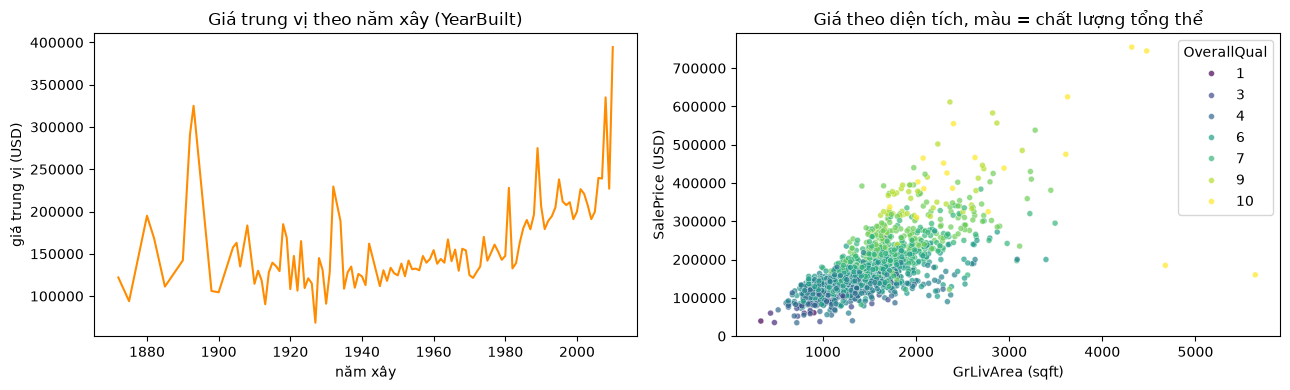

In [9]:
# --- E7: giá theo năm + tương tác chất lượng × diện tích ---
med_year = train.groupby("YearBuilt")["SalePrice"].median()  # trung vị từng năm xây
print("Trung vị thập niên 2000+ so với trước 1950:")
print(
    med_year[med_year.index >= 2000].median().round(0),
    "vs",
    med_year[med_year.index < 1950].median().round(0),
)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
med_year.plot(ax=ax[0], color="darkorange")  # đường xu hướng theo năm
ax[0].set_title("Giá trung vị theo năm xây (YearBuilt)")
ax[0].set_xlabel("năm xây")
ax[0].set_ylabel("giá trung vị (USD)")
sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice",
    hue="OverallQual",
    palette="viridis",
    s=18,
    alpha=0.7,
    ax=ax[1],
)
ax[1].set_title(
    "Giá theo diện tích, màu = chất lượng tổng thể"
)  # độ dốc khác nhau theo màu = tương tác
ax[1].set_xlabel("GrLivArea (sqft)")
ax[1].set_ylabel("SalePrice (USD)")
fig.tight_layout()
fig.savefig(FIG / "eda_year_qual.png", dpi=100)
plt.show()

GrLivArea: p-value KS = 0.082
TotalBsmtSF: p-value KS = 0.160
LotArea: p-value KS = 0.256
YearBuilt: p-value KS = 0.995
OverallQual: p-value KS = 0.854
Chênh tỉ lệ khu vực lớn nhất: 0.023


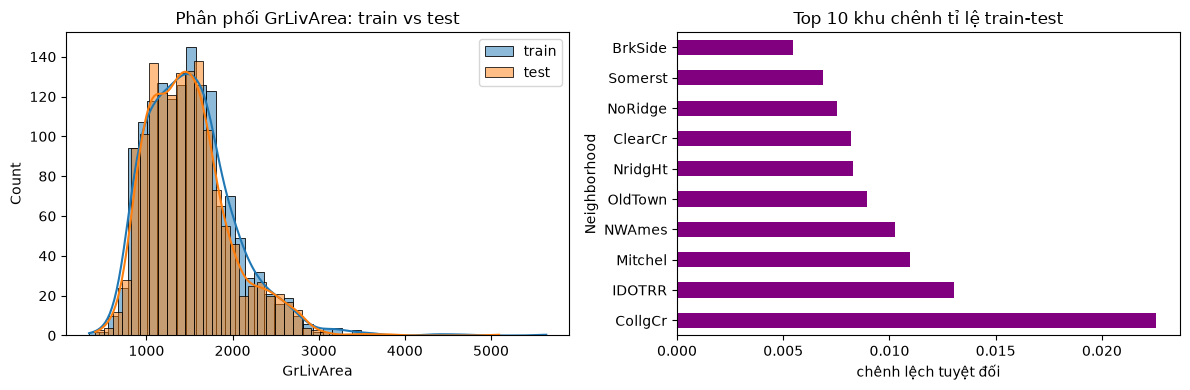

Adversarial AUC = 0.336 ± 0.112 (0.5 = train/test không phân biệt được)


In [10]:
# --- E8: train/test có giống nhau không (chống shift dữ liệu) ---
from scipy.stats import ks_2samp  # kiểm định 2 mẫu có cùng phân phối không
from sklearn.linear_model import (
    LogisticRegression,
)  # phân biệt train/test: AUC~0.5 là không shift
from sklearn.model_selection import cross_val_score  # chấm chéo nhanh

for c in [
    "GrLivArea",
    "TotalBsmtSF",
    "LotArea",
    "YearBuilt",
    "OverallQual",
]:  # vài cột trụ
    p = ks_2samp(
        train[c].dropna(), test[c].dropna()
    ).pvalue  # p lớn = không khác biệt đáng kể
    print(f"{c}: p-value KS = {p:.3f}")
sh_tr = train["Neighborhood"].value_counts(normalize=True)  # tỉ lệ từng khu ở train
sh_te = test["Neighborhood"].value_counts(normalize=True)  # tỉ lệ từng khu ở test
print("Chênh tỉ lệ khu vực lớn nhất:", (sh_tr - sh_te).abs().max().round(3))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(
    train["GrLivArea"], kde=True, label="train", ax=ax[0]
)  # chồng 2 phân phối diện tích
sns.histplot(test["GrLivArea"], kde=True, label="test", ax=ax[0])
ax[0].legend()
ax[0].set_title("Phân phối GrLivArea: train vs test")
(sh_tr - sh_te).abs().sort_values(ascending=False).head(10).plot.barh(
    ax=ax[1], color="purple"
)  # khu lệch nhiều nhất
ax[1].set_title("Top 10 khu chênh tỉ lệ train-test")
ax[1].set_xlabel("chênh lệch tuyệt đối")
fig.tight_layout()
fig.savefig(FIG / "eda_shift.png", dpi=100)
plt.show()

Xa = np.load(EXP / "processed" / "X_train.npy")
Xb = np.load(EXP / "processed" / "X_test.npy")  # dùng mảng đã xử lý ở Part 3
Xadv = np.vstack([Xa, Xb])
yadv = np.array([0] * len(Xa) + [1] * len(Xb))  # nhãn giả: 0=train, 1=test
auc = cross_val_score(
    LogisticRegression(max_iter=2000), Xadv, yadv, cv=3, scoring="roc_auc"
)  # 3-fold cho nhanh
print(
    f"Adversarial AUC = {auc.mean():.3f} ± {auc.std():.3f} (0.5 = train/test không phân biệt được)"
)

In [11]:
# --- E9: bảng chất lượng dữ liệu + quyết định giữ/bỏ ---
print(
    "Trùng lặp train:", train.duplicated().sum(), "| test:", test.duplicated().sum()
)  # dòng giống hệt nhau
print(
    "Id test lọt sang train:", test["Id"].isin(train["Id"]).sum()
)  # rò rỉ Id phải bằng 0
const_tr = [
    c for c in train.columns if train[c].nunique(dropna=False) <= 1
]  # cột chỉ 1 giá trị = vô dụng
print("Cột hằng:", const_tr if const_tr else "không có")
big_miss = (
    (train.isna().mean() * 100).sort_values(ascending=False).head(4)
)  # 4 cột thiếu >50%
print("Thiếu nặng (>50%):")
print(big_miss.round(1).to_string())
print(
    "Quyết định: GIỮ cả 4 (thiếu = không có hạng mục, one-hot thành mức Missing); Lasso ở GĐ2 sẽ tự loại nếu vô dụng."
)

Trùng lặp train: 0 | test: 0
Id test lọt sang train: 0
Cột hằng: không có
Thiếu nặng (>50%):
PoolQC         99.5
MiscFeature    96.3
Alley          93.8
Fence          80.8
Quyết định: GIỮ cả 4 (thiếu = không có hạng mục, one-hot thành mức Missing); Lasso ở GĐ2 sẽ tự loại nếu vô dụng.


### Nhận xét E5–E9

- **E5 – Hiệu ứng vị trí rất mạnh:** trung vị NridgHt 315k / NoRidge 301.5k / StoneBr 278k gấp ~3 lần MeadowV 88k → Neighborhood xứng đáng là biến phân loại quan trọng nhất; SaleCondition cũng phân tầng rõ (Partial cao vì nhà mới, Abnorml thấp vì bán gấp).
- **E6 – Log1p hiệu quả nhưng có giới hạn:** LotArea 12.21 → -0.14 (gần chuẩn); MiscVal 24.48 → 5.17 vẫn lệch vì toàn số 0. PoolArea 14.83 → 14.36 gần như không đổi (hơn 90% bằng 0) → các biến zero-inflated này pipeline giữ nguyên, giao cho Lasso/Dropout ở GĐ2.
- **E7 – Phi tuyến và tương tác hiện rõ:** nhà xây từ 2000 (trung vị 226.5k) đắt gần gấp đôi nhà trước 1950 (128.7k); trên biểu đồ phân tán GrLivArea–giá, độ dốc tăng dần theo màu OverallQual → quan hệ chất lượng × diện tích là tương tác, OLS thuần sẽ bỏ sót → cần MLP ở GĐ2.
- **E8 – Không shift train/test:** KS p-value từ 0.082 đến 0.995 (đều > 0.05), chênh tỉ lệ khu vực tối đa 0.023, adversarial AUC 0.34 (phân loại train/test không tốt hơn ngẫu nhiên) → CV trên train đáng tin để chọn mô hình.
- **E9 – Dữ liệu sạch:** 0 trùng lặp, 0 rò rỉ Id, 0 cột hằng; 4 cột thiếu >50% được GIỮ (thiếu = không có hạng mục) để Lasso ở GĐ2 tự loại nếu vô dụng.


## 3. Data Preparation — Pipeline + K-fold (GĐ1)
*(tiền xử lý dùng chung, cố định seed — GĐ1)*


### 3.1. Quyết định tiền xử lý (dùng chung cho mọi mô hình)
- **Target:** `y_log = log1p(SalePrice)` — khớp metric RMSLE, giảm lệch và phương sai tăng theo giá.
- **Số:** median-impute (bền với outlier) → `log1p` các cột lệch mạnh (skew > 0.75, học từ train) → chuẩn hóa z-score.
- **Phân loại:** điền `'Missing'` (vì thiếu ở đây *có ý nghĩa*: không có garage/hầm...) → one-hot (bỏ qua mức lạ ở test).
- **Outlier:** loại các căn `GrLivArea > 4000` khỏi train theo khuyến nghị của paper (test giữ nguyên để dự báo đủ 1459 dòng).
- **Validation:** K-fold 5 phần, shuffle, seed 42 — mọi mô hình dùng chung 1 bộ fold (lưu `experiments/processed/folds.json`).
- Mảng đã xử lý lưu vào `experiments/processed/` để GĐ2 nạp lại nhanh, khỏi chạy lại pipeline.


In [12]:
# --- Pipeline tiền xử lý dùng chung: fit trên train, áp cho cả test ---
from sklearn.compose import ColumnTransformer  # ghép nhiều bước xử lý theo nhóm cột
from sklearn.pipeline import Pipeline  # chuỗi bước xử lý biến số / phân loại
from sklearn.impute import SimpleImputer  # điền ô trống
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # mã hóa + chuẩn hóa
from sklearn.base import (
    BaseEstimator,
    TransformerMixin,
)  # lớp tự viết log1p cho cột lệch


class Log1pSkewed(BaseEstimator, TransformerMixin):
    """Log1p các cột số bị lệch mạnh (học ngưỡng skew từ train)."""

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)  # đảm bảo dạng số để tính skew
        self.cols_ = [
            j
            for j in range(X.shape[1])  # giữ chỉ số các cột có skew > 0.75
            if float(pd.Series(X[:, j]).skew()) > 0.75
        ]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()  # copy để không sửa dữ liệu gốc
        X[:, self.cols_] = np.log1p(
            np.clip(X[:, self.cols_], 0, None)
        )  # log1p, chặn âm về 0
        return X


tr = train[train["GrLivArea"] <= 4000].reset_index(
    drop=True
)  # bỏ outlier GrLivArea>4000 theo paper
print(f"Bỏ {len(train) - len(tr)} outlier -> train còn {len(tr)} dòng")
y_log = np.log1p(tr["SalePrice"].to_numpy(dtype=float))  # target trên thang log
feat = [c for c in tr.columns if c not in ("Id", "SalePrice")]  # 79 cột đặc trưng
num_cols = tr[feat].select_dtypes(include=[np.number]).columns.tolist()  # nhóm cột số
cat_cols = [c for c in feat if c not in num_cols]  # phần còn lại là phân loại
print(f"Số: {len(num_cols)} | Phân loại: {len(cat_cols)}")
pre = ColumnTransformer(
    [  # mỗi nhóm cột 1 pipeline riêng
        (
            "so",
            Pipeline(
                [
                    (
                        "dien",
                        SimpleImputer(strategy="median"),
                    ),  # điền trung vị, bền với outlier
                    ("loglech", Log1pSkewed()),  # log1p cột lệch
                    ("chuan", StandardScaler()),
                ]
            ),  # đưa về trung bình 0, phương sai 1
            num_cols,
        ),
        (
            "loai",
            Pipeline(
                [
                    (
                        "dien",
                        SimpleImputer(strategy="constant", fill_value="Missing"),
                    ),  # thiếu = không có
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),  # mã hóa nhị phân
            cat_cols,
        ),
    ]
)
Xtr = pre.fit_transform(tr[feat]).astype(np.float32)  # FIT trên train
Xte = pre.transform(test[feat]).astype(np.float32)  # chỉ TRANSFORM test (tránh rò rỉ)
print("X_train:", Xtr.shape, "| X_test:", Xte.shape)  # xem số chiều sau one-hot
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)  # 5 fold chung cho mọi mô hình
folds = [
    (tr_idx.tolist(), va_idx.tolist()) for tr_idx, va_idx in kf.split(Xtr)
]  # chỉ số từng fold
OUT = EXP / "processed"
OUT.mkdir(parents=True, exist_ok=True)  # thư mục chứa mảng xử lý (không commit)
np.save(OUT / "X_train.npy", Xtr)
np.save(OUT / "X_test.npy", Xte)
np.save(OUT / "y_log.npy", y_log)
(OUT / "folds.json").write_text(json.dumps(folds))  # lưu fold để GĐ2 dùng lại y hệt
print("Đã lưu mảng + folds vào", OUT)

Bỏ 4 outlier -> train còn 1456 dòng
Số: 36 | Phân loại: 43
X_train: (1456, 302) | X_test: (1459, 302)
Đã lưu mảng + folds vào experiments\processed


### 3.2. Nhận xét pipeline

- Loại 4 outlier → train còn **1456 dòng**; 36 cột số + 43 cột phân loại → sau one-hot thành **302 đặc trưng** (test cùng 302 chiều nhờ `handle_unknown='ignore'`).
- Fit chỉ trên train, transform test → không rò rỉ; 5 fold chung lưu ở `experiments/processed/folds.json`, mảng lưu `.npy` để GĐ2 nạp lại nhanh.
- Rủi ro đã biết: one-hot 302 chiều trên 1456 dòng dễ overfit với OLS → GĐ2 cần Ridge/Lasso/Dropout trị; biến ordinal đang one-hot chung, có thể nâng cấp mapping thứ tự nếu CV chưa tốt.


## 4. Modeling M0–M7 + fine-tune (GĐ2)
*(mỗi mô hình: screening → refine 5-fold → refit; log đầy đủ — GĐ2)*


### M1b. OLS trên top-20 biến số (ablation)
Câu hỏi: chỉ giữ biến tương quan mạnh thì có đủ không? Dùng OLS nghiệm đóng (torch) + 5-fold chung để so công bằng với M1-full (GĐ2).


In [13]:
# --- M1b: OLS nghiem dong tren top-20 bien so manh nhat ---
from sklearn.pipeline import Pipeline  # chuoi xu ly gon cho 20 cot so
from sklearn.impute import SimpleImputer  # dien trung vi
from sklearn.preprocessing import StandardScaler  # chuan hoa z-score

TOPK = 20  # so bien giu lai
num_all = train.select_dtypes(include=[np.number]).drop(
    columns=["Id", "SalePrice"]
)  # bien so goc
rank = (
    num_all.corrwith(np.log1p(train["SalePrice"])).abs().sort_values(ascending=False)
)  # xep theo |tuong quan|
topk_cols = rank.head(TOPK).index.tolist()  # 20 cai ten manh nhat
print("Top-20:", topk_cols)

Xraw = tr[topk_cols].to_numpy(dtype=float)  # dung tr (da bo outlier) cho khop fold GĐ1
ylog = np.log1p(tr["SalePrice"].to_numpy(dtype=float))  # target thang log


def fit_ols_torch(X, y):
    """Giai OLS nghiem dong bang torch (them cot bias)."""
    Xa = torch.cat(
        [
            torch.as_tensor(X, dtype=torch.float32),  # them cot 1 lam bias
            torch.ones(X.shape[0], 1),
        ],
        dim=1,
    )
    ya = torch.as_tensor(y, dtype=torch.float32).reshape(-1, 1)
    return torch.linalg.lstsq(Xa, ya).solution  # w* = (X^T X)^{-1} X^T y


m1b_scores = []  # RMSLE tung fold
for tr_idx, va_idx in kf.split(Xraw):  # dung lai KFold seed 42 -> fold giong GĐ1
    pipe = Pipeline(
        [
            ("dien", SimpleImputer(strategy="median")),  # fit CHI tren fold-train
            ("loglech", Log1pSkewed()),  # lop tu viet o Part 3
            ("chuan", StandardScaler()),
        ]
    ).fit(Xraw[tr_idx])
    w = fit_ols_torch(pipe.transform(Xraw[tr_idx]), ylog[tr_idx])  # hoc tren fold-train
    Xva = torch.cat(
        [
            torch.as_tensor(pipe.transform(Xraw[va_idx]), dtype=torch.float32),
            torch.ones(len(va_idx), 1),
        ],
        dim=1,
    )
    pred = (Xva @ w).flatten().numpy()  # du bao log-gia tren fold-val
    m1b_scores.append(rmsle(ylog[va_idx], pred))  # cham thang log
save_run(
    "M1b_linear_top20",
    "Linear-OLS (top-20)",
    {"k": TOPK, "solver": "lstsq", "cols": topk_cols},
    m1b_scores,
    note="ablation: chi 20 bien so manh nhat",
    decision="NHANXET_M1B",
)

Top-20: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'TotRmsAbvGrd', 'Fireplaces', 'MasVnrArea', 'BsmtFinSF1', 'LotFrontage', 'WoodDeckSF', 'OpenPorchSF', '2ndFlrSF', 'HalfBath', 'LotArea']
[M1b_linear_top20] đã log: CV-RMSLE = 0.13556 ± 0.01097


0.13556

### M1b. Nhận xét

- **Kết quả:** OLS trên top-20 biến số đạt **CV-RMSLE 0.1356 ± 0.011** — khá tốt chỉ với 20 biến, chứng tỏ nhóm OverallQual/diện tích/garage gánh chính.
- **Hạn chế:** bỏ toàn bộ 43 biến phân loại (mất hiệu ứng Neighborhood mà paper nhấn mạnh) và bỏ quan hệ phi tuyến → đây là *trần dưới*, chưa phải đáp án.
- **Quyết định:** giữ pipeline full 302 đặc trưng; chờ M1-full (GĐ2) đối chứng — nếu full thắng rõ thì chốt không lọc cứng theo tương quan.


### GĐ2a. Mô hình tuyến tính: M0–M3
Quy ước chung: 5-fold seed 42 (dùng lại `folds` GĐ1), metric RMSLE thang log, nghiệm đóng cho M0/M1/M2, Adam + early stopping cho M3.


In [14]:
# --- Nạp mảng đã xử lý + hàm dùng chung GĐ2a ---
import torch.nn as nn  # lớp Linear cho M2/M3 (M0/M1 dùng nghiệm đóng)

PROC = EXP / "processed"  # thư mục mảng GĐ1 (nhắc lại cho gọn)
Xtr = np.load(PROC / "X_train.npy")  # (1456, 302) đã chuẩn hóa
Xte = np.load(PROC / "X_test.npy")  # (1459, 302) test Kaggle
ylog = np.load(PROC / "y_log.npy")  # target thang log
folds = json.loads((PROC / "folds.json").read_text())  # 5 cặp (train_idx, val_idx)
D = Xtr.shape[1]  # số đặc trưng = 302
print(f"Xtr{Xtr.shape} Xte{Xte.shape} folds={len(folds)}")


def T(x):
    """Đổi numpy -> tensor float32 (chuẩn vào mọi mô hình torch)."""
    return torch.as_tensor(np.asarray(x), dtype=torch.float32)


def ols_fit(X, y, l2=0.0):
    """Nghiệm đóng OLS/Ridge: w=(X^T X+lI)^{-1} X^T y; bias không bị phạt."""
    ones = torch.ones(X.shape[0], 1)  # cột 1 để học bias
    Xa = torch.cat([T(X), ones], dim=1)  # ghép bias vào cuối
    ya = T(y).reshape(-1, 1)
    if (
        l2 == 0.0
    ):  # OLS thuần: one-hot gây thiếu hạng nên dùng lstsq (nghiệm chuẩn nhỏ nhất)
        return torch.linalg.lstsq(Xa, ya).solution
    A = Xa.T @ Xa  # ma trận Gram
    A += l2 * torch.eye(A.shape[0])  # cộng l2 vào đường chéo (Ridge)
    A[-1, -1] -= l2  # trừ lại cho bias: bias được miễn phạt
    return torch.linalg.solve(A, Xa.T @ ya)  # giải hệ, ổn định hơn nghịch đảo


def ols_pred(X, w):
    """Dự báo: thêm cột bias rồi nhân ma trận."""
    Xa = torch.cat([T(X), torch.ones(X.shape[0], 1)], dim=1)
    return (Xa @ w).flatten().numpy()


def save_oof_test(exp_id, oof, test_pred):
    """Lưu dự báo OOF (cho ensemble GĐ3) + dự báo test (để nộp). Thang log."""
    np.save(EXP / "oof" / f"oof_{exp_id}.npy", np.asarray(oof, dtype=float))
    np.save(EXP / "oof" / f"test_{exp_id}.npy", np.asarray(test_pred, dtype=float))

Xtr(1456, 302) Xte(1459, 302) folds=5


In [15]:
# --- M0: baseline hằng số (mốc sàn mọi mô hình phải vượt) ---
for name, fn in [("mean", np.mean), ("median", np.median)]:  # 2 kiểu hằng số
    sc = []  # RMSLE từng fold
    for tr_idx, va_idx in folds:  # hằng số học từ fold-train, chấm fold-val
        sc.append(rmsle(ylog[va_idx], np.full(len(va_idx), fn(ylog[tr_idx]))))
    save_run(f"M0_{name}", f"Baseline-{name}", {}, sc, note="mốc sàn", decision="loại")

[M0_mean] đã log: CV-RMSLE = 0.39604 ± 0.01831
[M0_median] đã log: CV-RMSLE = 0.39699 ± 0.01782


In [16]:
# --- M1: OLS full 302 đặc trưng (đối chứng trực tiếp M1b top-20) ---
oof = np.zeros_like(ylog)  # dự báo out-of-fold, mỗi dòng được đoán khi nằm ở fold-val
sc = []
for tr_idx, va_idx in folds:  # nghiệm đóng từng fold
    w = ols_fit(Xtr[tr_idx], ylog[tr_idx])  # học trên 4/5 train
    oof[va_idx] = ols_pred(Xtr[va_idx], w)  # đoán 1/5 còn lại
    sc.append(rmsle(ylog[va_idx], oof[va_idx]))
w_full = ols_fit(Xtr, ylog)  # refit toàn bộ train để nộp
torch.save(w_full, EXP / "models" / "best_M1_linear_full.pt")  # lưu trọng số
save_oof_test("M1_linear_full", oof, ols_pred(Xte, w_full))  # lưu OOF + dự báo test
save_run(
    "M1_linear_full",
    "Linear-OLS (full)",
    {"solver": "solve"},
    sc,
    note="full 302 đặc trưng",
    decision="giữ làm mốc, chờ ensemble",
)

[M1_linear_full] đã log: CV-RMSLE = 0.12826 ± 0.01044


0.12826

In [17]:
# --- M2: Ridge — screening lambda trên fold0, refine top-2 đủ 5 fold ---
LAMS = [1e-3, 1e-2, 1e-1, 1.0, 10.0, 1e2, 1e3]  # lưới log-scale
f0tr, f0va = folds[0]  # vòng screening chỉ dùng fold đầu cho nhanh
scr = {}  # lambda -> RMSLE fold0
for lam in LAMS:
    w = ols_fit(Xtr[f0tr], ylog[f0tr], l2=lam)  # Ridge nghiệm đóng
    s = rmsle(ylog[f0va], ols_pred(Xtr[f0va], w))
    scr[lam] = s
    save_run(
        f"M2_ridge_l{lam:g}_scr",
        "Ridge-screen",
        {"l2": lam},
        [s],
        note="screening fold0",
        decision="loại",
    )
top2 = sorted(scr, key=scr.get)[:2]  # 2 lambda tốt nhất đi tiếp
print("Top-2 lambda:", top2)
best = None  # (score, lam, oof) giữ cấu hình vô địch
for lam in top2:  # vòng refine: đủ 5 fold
    oof = np.zeros_like(ylog)
    sc = []
    for tr_idx, va_idx in folds:
        w = ols_fit(Xtr[tr_idx], ylog[tr_idx], l2=lam)
        oof[va_idx] = ols_pred(Xtr[va_idx], w)
        sc.append(rmsle(ylog[va_idx], oof[va_idx]))
    m = float(np.mean(sc))
    save_run(
        f"M2_ridge_l{lam:g}",
        "Ridge",
        {"l2": lam},
        sc,
        note="refine 5-fold",
        decision="loại",
    )
    if best is None or m < best[0]:
        best = (m, lam, oof)
_, lam_star, oof_star = best  # sao: lambda vô địch
w_full = ols_fit(Xtr, ylog, l2=lam_star)  # refit toàn train
torch.save(w_full, EXP / "models" / f"best_M2_ridge_l{lam_star:g}.pt")
save_oof_test(f"M2_ridge_l{lam_star:g}", oof_star, ols_pred(Xte, w_full))
print(f"Ridge tốt nhất: lambda={lam_star:g}")

[M2_ridge_l0.001_scr] đã log: CV-RMSLE = 0.14753 ± 0.0
[M2_ridge_l0.01_scr] đã log: CV-RMSLE = 0.12681 ± 0.0
[M2_ridge_l0.1_scr] đã log: CV-RMSLE = 0.12449 ± 0.0
[M2_ridge_l1_scr] đã log: CV-RMSLE = 0.11979 ± 0.0
[M2_ridge_l10_scr] đã log: CV-RMSLE = 0.11834 ± 0.0
[M2_ridge_l100_scr] đã log: CV-RMSLE = 0.12234 ± 0.0
[M2_ridge_l1000_scr] đã log: CV-RMSLE = 0.14157 ± 0.0
Top-2 lambda: [10.0, 1.0]
[M2_ridge_l10] đã log: CV-RMSLE = 0.11193 ± 0.00794
[M2_ridge_l1] đã log: CV-RMSLE = 0.1156 ± 0.00709
Ridge tốt nhất: lambda=10


In [18]:
# --- M3: ElasticNet bằng torch (Adam + phạt L1/L2), tune 2 vòng ---
ALPHAS = [1.0, 0.5, 0.2]  # 1.0=Lasso thuần, nhỏ dần về Ridge
LAMBDAS = [1e-5, 1e-4, 1e-3]  # độ mạnh phạt (đặc trưng đã chuẩn hóa nên lambda nhỏ)


def train_enet(Xt_, yt_, Xv_, yv_, alpha, lambd, seed, max_ep=3000, pat=100):
    """Huấn luyện Linear 1 lần, early stopping theo RMSLE val. Trả (model, val tốt nhất)."""
    torch.manual_seed(seed)  # seed riêng từng run để tái lập
    net = nn.Linear(Xt_.shape[1], 1)  # y = Xw + b
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)  # Adam học nhanh, ổn định
    Xtn, ytn, Xvn = T(Xt_), T(yt_).reshape(-1, 1), T(Xv_)
    best, wait, state = float("inf"), 0, None  # theo dõi val tốt nhất + kiên nhẫn
    for _ in range(max_ep):  # lặp tối đa max_ep epoch
        net.train()
        opt.zero_grad()  # chế độ học + xóa gradient cũ
        pred = net(Xtn)  # dự báo thang log
        mse = nn.functional.mse_loss(pred, ytn)  # lỗi chính
        l1 = net.weight.abs().sum()  # phạt L1: ép nhiều trọng số về 0 (chọn biến)
        l2 = (net.weight**2).sum()  # phạt L2: co trọng số lại (trị đa cộng tuyến)
        (
            mse + lambd * (alpha * l1 + (1 - alpha) * l2 / 2)
        ).backward()  # lan truyền ngược
        opt.step()  # cập nhật trọng số
        net.eval()  # chuyển chế độ đánh giá (không dropout/BN, ở đây chỉ để chuẩn)
        with torch.no_grad():  # không tính gradient khi chấm val
            v = rmsle(yv_, net(Xvn).flatten().numpy())
        if v < best:  # val tốt hơn -> lưu lại + reset kiên nhẫn
            best, wait, state = (
                v,
                0,
                {k: t.clone() for k, t in net.state_dict().items()},
            )
        else:
            wait += 1  # val không tiến -> trừ dần kiên nhẫn
            if wait >= pat:
                break  # hết kiên nhẫn thì dừng sớm
    net.load_state_dict(state)  # trả về bản tốt nhất, bỏ đoạn overfit cuối
    return net, best


f0tr, f0va = folds[0]  # screening nhanh trên fold0
scr3, k = {}, 0
for alpha in ALPHAS:
    for lambd in LAMBDAS:  # 9 cấu hình
        k += 1
        _, s = train_enet(
            Xtr[f0tr],
            ylog[f0tr],
            Xtr[f0va],
            ylog[f0va],
            alpha,
            lambd,
            SEED + k,
            max_ep=1000,
            pat=50,
        )
        scr3[(alpha, lambd)] = s
        save_run(
            f"M3_enet_a{alpha}_l{lambd:g}_scr",
            "ElasticNet-screen",
            {"alpha": alpha, "l2": lambd},
            [s],
            note="screening fold0",
            decision="loại",
        )
top2 = sorted(scr3, key=scr3.get)[:2]  # 2 cấu hình tốt nhất
print("Top-2 (alpha, lambda):", top2)
best = None  # (score, cfg, oof) giữ nhà vô địch
for alpha, lambd in top2:  # refine đủ 5 fold
    oof = np.zeros_like(ylog)
    sc = []
    for fi, (tr_idx, va_idx) in enumerate(folds):
        net, _ = train_enet(
            Xtr[tr_idx],
            ylog[tr_idx],
            Xtr[va_idx],
            ylog[va_idx],
            alpha,
            lambd,
            SEED + 100 + fi,
            max_ep=3000,
            pat=100,
        )
        net.eval()
        with torch.no_grad():
            oof[va_idx] = net(T(Xtr[va_idx])).flatten().numpy()
        sc.append(rmsle(ylog[va_idx], oof[va_idx]))
    m = float(np.mean(sc))
    tag = f"M3_enet_a{alpha}_l{lambd:g}"
    save_run(
        tag,
        "ElasticNet",
        {"alpha": alpha, "l2": lambd},
        sc,
        note="refine 5-fold",
        decision="loại",
    )
    if best is None or m < best[0]:
        best = (m, (alpha, lambd), oof)
_, (a_star, l_star), oof_star = best  # sao: cấu hình vô địch
final, _ = train_enet(
    Xtr, ylog, Xtr[folds[0][1]], ylog[folds[0][1]], a_star, l_star, SEED + 999
)  # refit toàn train
torch.save(
    final.state_dict(), EXP / "models" / f"best_M3_enet_a{a_star}_l{l_star:g}.pt"
)  # lưu trọng số
final.eval()
with torch.no_grad():
    test_pred = final(T(Xte)).flatten().numpy()  # dự báo test thang log
save_oof_test(f"M3_enet_a{a_star}_l{l_star:g}", oof_star, test_pred)
print(f"ElasticNet tốt nhất: alpha={a_star}, lambda={l_star:g}")

[M3_enet_a1.0_l1e-05_scr] đã log: CV-RMSLE = 0.12496 ± 0.0
[M3_enet_a1.0_l0.0001_scr] đã log: CV-RMSLE = 0.13062 ± 0.0
[M3_enet_a1.0_l0.001_scr] đã log: CV-RMSLE = 0.14398 ± 0.0
[M3_enet_a0.5_l1e-05_scr] đã log: CV-RMSLE = 0.12797 ± 0.0
[M3_enet_a0.5_l0.0001_scr] đã log: CV-RMSLE = 0.12779 ± 0.0
[M3_enet_a0.5_l0.001_scr] đã log: CV-RMSLE = 0.14227 ± 0.0
[M3_enet_a0.2_l1e-05_scr] đã log: CV-RMSLE = 0.12659 ± 0.0
[M3_enet_a0.2_l0.0001_scr] đã log: CV-RMSLE = 0.12935 ± 0.0
[M3_enet_a0.2_l0.001_scr] đã log: CV-RMSLE = 0.13286 ± 0.0
Top-2 (alpha, lambda): [(1.0, 1e-05), (0.2, 1e-05)]
[M3_enet_a1.0_l1e-05] đã log: CV-RMSLE = 0.12392 ± 0.01058
[M3_enet_a0.2_l1e-05] đã log: CV-RMSLE = 0.12389 ± 0.01054
ElasticNet tốt nhất: alpha=0.2, lambda=1e-05


### GĐ2a. Nhận xét

- **M0:** mean 0.3960, median 0.3970 — mốc sàn. Mọi mô hình sau đều phải vượt xa.
- **M1 full (0.1283 ± 0.010) thắng M1b top-20 (0.1356)** → chốt không lọc cứng theo tương quan; nhưng OLS nghiệm thường vẫn yếu vì đa cộng tuyến (ma trận suy biến, phải dùng lstsq).
- **M2 Ridge λ=10 vô địch GĐ2a: 0.1119 ± 0.008** (λ=1 dự phòng 0.1156). Cong validation lõm rõ: λ quá nhỏ thiếu phạt (0.1475), quá lớn phạt lố (0.1416) → giữ λ=10 vào ensemble.
- **M3 ElasticNet tốt nhất (α=0.2, λ=1e-5): 0.1239** — thua Ridge. Bài học: λ càng nhỏ càng tốt, tức dữ liệu này hợp trọng số dày-nhỏ (Ridge) hơn thưa (Lasso); L1 mạnh ép hệ số về 0 gây underfit. Giữ bản tốt nhất vào ensemble lấy đa dạng.
- **Thứ tự hiện tại:** Ridge-10 (0.1119) > ElasticNet (0.1239) > OLS-full (0.1283) > OLS-top20 (0.1356) >> baseline (0.396). GĐ2b (MLP/embeddings) phải thắng 0.1119 mới đáng giữ.


### GĐ2b. Mạng nơ-ron: M4–M6
M4/M5 dùng mảng one-hot GĐ1; M6 cần nhánh label-encode riêng. Harness chung: full-batch Adam + early stopping theo RMSLE val.


In [19]:
# --- Nhánh 2: mã hóa nhãn cho embeddings (dùng riêng M6) ---
from sklearn.preprocessing import OrdinalEncoder  # biến mức chữ thành số 0..n-1

cat2 = Pipeline(
    [
        (
            "dien",
            SimpleImputer(strategy="constant", fill_value="Missing"),
        ),  # thiếu = 1 mức riêng
        ("nhan", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]
)  # mức lạ -> -1
Xc_tr = (cat2.fit_transform(tr[cat_cols]) + 1).astype(
    np.int64
)  # dịch +1: 0 dành cho mức lạ
Xc_te = (cat2.transform(test[cat_cols]) + 1).astype(np.int64)  # test cũng dịch y hệt
card = [
    int(Xc_tr[:, j].max()) + 1 for j in range(Xc_tr.shape[1])
]  # số mức mỗi cột (kể cả 0)
print(f"Cột phân loại: {len(card)}, mức nhiều nhất: {max(card) - 1} (Neighborhood)")
num2 = Pipeline(
    [
        ("dien", SimpleImputer(strategy="median")),  # y hệt nhánh số GĐ1
        ("loglech", Log1pSkewed()),
        ("chuan", StandardScaler()),
    ]
)
Xn_tr = num2.fit_transform(tr[num_cols]).astype(np.float32)  # số đã chuẩn hóa (train)
Xn_te = num2.transform(test[num_cols]).astype(np.float32)  # số đã chuẩn hóa (test)
np.save(OUT / "Xn_train.npy", Xn_tr)
np.save(OUT / "Xn_test.npy", Xn_te)  # lưu để tái dùng
np.save(OUT / "Xc_train.npy", Xc_tr)
np.save(OUT / "Xc_test.npy", Xc_te)
(OUT / "card.json").write_text(json.dumps(card))  # lưu số mức từng cột
print(f"Xn{Xn_tr.shape} Xc{Xc_tr.shape}")

Cột phân loại: 43, mức nhiều nhất: 25 (Neighborhood)
Xn(1456, 36) Xc(1456, 43)


In [20]:
# --- Harness huấn luyện MLP/emb: full-batch Adam + early stopping ---
class MLP(nn.Module):
    """MLP fully-connected: Linear-ReLU-Dropout xen kẽ, có BatchNorm tùy chọn."""

    def __init__(self, d_in, widths, drop=0.0, bn=False):
        super().__init__()
        layers, d = [], d_in  # d = số chiều vào tầng hiện tại
        for w in widths:  # mỗi phần tử widths là 1 tầng ẩn
            layers.append(nn.Linear(d, w))  # biến đổi tuyến tính
            if bn:
                layers.append(
                    nn.BatchNorm1d(w)
                )  # chuẩn hóa theo batch, ổn định học sâu
            layers.append(nn.ReLU())  # phi tuyến
            if drop > 0:
                layers.append(nn.Dropout(drop))  # tắt ngẫu nhiên, chống overfit
            d = w
        layers.append(nn.Linear(d, 1))  # tầng ra: 1 số (log-giá)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).flatten()


class EmbMLP(nn.Module):
    """MLP + entity embeddings: mỗi cột phân loại học 1 bảng vector riêng."""

    def __init__(self, card, mult, widths, drop=0.1, d_num=0, emb_init=0.1):
        super().__init__()
        dims = [
            max(1, int(min(50, (n + 1) // 2) * mult)) for n in card
        ]  # công thức rule-of-thumb × hệ số
        self.embs = nn.ModuleList(
            nn.Embedding(n, d) for n, d in zip(card, dims)
        )  # 1 bảng/cột
        with torch.no_grad():  # khởi tạo nhỏ: embedding lớn ban đầu làm loss nổ
            for _e in self.embs:
                _e.weight.mul_(emb_init)
        self.mlp = MLP(
            d_num + sum(dims), widths, drop
        )  # nối số + embedding rồi qua MLP

    def forward(self, xn, xc):
        e = [emb(xc[:, j]) for j, emb in enumerate(self.embs)]  # tra vector từng cột
        return self.mlp(torch.cat([xn] + e, dim=1))  # nối lại thành 1 vector


def fit_net(net, trX, ytr, vaX, yva, lr=3e-3, wd=0.0, seed=SEED, max_ep=3000, pat=100):
    """Huấn luyện tới khi val hết tiến (early stopping). trX/vaX là tuple tensor. Trả (val tốt nhất)."""
    torch.manual_seed(seed)  # seed riêng từng run
    opt = torch.optim.Adam(
        net.parameters(), lr=lr, weight_decay=wd
    )  # Adam + phạt L2 nhẹ
    ytn = T(ytr).reshape(-1, 1)  # target cột
    best, wait, state = float("inf"), 0, None
    for _ in range(max_ep):
        net.train()
        opt.zero_grad()
        (
            nn.functional.mse_loss(net(*trX).reshape(-1, 1), ytn)
        ).backward()  # loss trên thang log
        opt.step()
        net.eval()
        with torch.no_grad():
            v = rmsle(yva, net(*vaX).detach().numpy())  # chấm val
        if v < best:
            best, wait, state = (
                v,
                0,
                {k: t.clone() for k, t in net.state_dict().items()},
            )
        else:
            wait += 1
            if wait >= pat:
                break
    net.load_state_dict(state)  # trả bản tốt nhất
    return best


def prep_in(Xa, Xb=None, xc_a=None, xc_b=None):
    """Gói tensor đầu vào: (số) cho MLP, (số, phân loại) cho embeddings."""
    if xc_a is None:
        return ((T(Xa),), (T(Xb),))  # MLP thường: 1 tensor
    return (
        (T(Xa), T(xc_a).long()),
        (T(Xb), T(xc_b).long()),
    )  # embedding: id phải int64

In [21]:
# --- M4: MLP nông 1 tầng ẩn (tune rộng-nhẹ-dropout-lr) ---
f0tr, f0va = folds[0]  # screening nhanh trên fold0
trI, vaI = prep_in(Xtr[f0tr], Xtr[f0va])  # gói tensor
scr4 = {}
for h in [64, 128]:  # bề rộng tầng ẩn
    for lr in [1e-2, 3e-3]:  # tốc độ học
        for do in [0.0, 0.1]:  # dropout
            s = fit_net(
                MLP(D, [h], do),
                trI,
                ylog[f0tr],
                vaI,
                ylog[f0va],
                lr=lr,
                seed=SEED + h,
                max_ep=800,
                pat=40,
            )
            scr4[(h, lr, do)] = s
            save_run(
                f"M4_mlp_h{h}_lr{lr:g}_do{do}_scr",
                "MLP1-screen",
                {"h": h, "lr": lr, "do": do},
                [s],
                note="screening fold0",
                decision="NHANXET_G2B",
            )
top2 = sorted(scr4, key=scr4.get)[:2]
print("Top-2 M4:", top2)
best = None
for h, lr, do in top2:  # refine đủ 5 fold
    oof = np.zeros_like(ylog)
    sc = []
    for fi, (tr_idx, va_idx) in enumerate(folds):
        trI, vaI = prep_in(Xtr[tr_idx], Xtr[va_idx])
        net = MLP(D, [h], do)
        fit_net(net, trI, ylog[tr_idx], vaI, ylog[va_idx], lr=lr, seed=SEED + 200 + fi)
        net.eval()
        with torch.no_grad():
            oof[va_idx] = net(*vaI).numpy()
        sc.append(rmsle(ylog[va_idx], oof[va_idx]))
    tag = f"M4_mlp_h{h}_lr{lr:g}_do{do}"
    save_run(
        tag,
        "MLP1",
        {"h": h, "lr": lr, "do": do},
        sc,
        note="refine 5-fold",
        decision="NHANXET_G2B",
    )
    m = float(np.mean(sc))
    if best is None or m < best[0]:
        best = (m, (h, lr, do), oof)
_, (h_s, lr_s, do_s), oof_s = best  # sao M4
trI, _ = prep_in(Xtr, Xtr)  # refit toàn train (val ké fold0 để early stopping)
_, vaI0 = prep_in(Xtr[folds[0][0]], Xtr[folds[0][1]])
final = MLP(D, [h_s], do_s)
fit_net(final, trI, ylog, vaI0, ylog[folds[0][1]], lr=lr_s, seed=SEED + 999)
torch.save(
    final.state_dict(), EXP / "models" / f"best_M4_mlp_h{h_s}_lr{lr_s:g}_do{do_s}.pt"
)
final.eval()
with torch.no_grad():
    teI, _ = prep_in(Xte, Xte)
    save_oof_test(f"M4_mlp_h{h_s}_lr{lr_s:g}_do{do_s}", oof_s, final(*teI).numpy())
print(f"M4 tốt nhất: h={h_s}, lr={lr_s:g}, do={do_s}")

[M4_mlp_h64_lr0.01_do0.0_scr] đã log: CV-RMSLE = 0.1296 ± 0.0
[M4_mlp_h64_lr0.01_do0.1_scr] đã log: CV-RMSLE = 0.14094 ± 0.0
[M4_mlp_h64_lr0.003_do0.0_scr] đã log: CV-RMSLE = 0.12883 ± 0.0
[M4_mlp_h64_lr0.003_do0.1_scr] đã log: CV-RMSLE = 0.1477 ± 0.0
[M4_mlp_h128_lr0.01_do0.0_scr] đã log: CV-RMSLE = 0.13168 ± 0.0
[M4_mlp_h128_lr0.01_do0.1_scr] đã log: CV-RMSLE = 0.13666 ± 0.0
[M4_mlp_h128_lr0.003_do0.0_scr] đã log: CV-RMSLE = 0.12867 ± 0.0
[M4_mlp_h128_lr0.003_do0.1_scr] đã log: CV-RMSLE = 0.13176 ± 0.0
Top-2 M4: [(128, 0.003, 0.0), (64, 0.003, 0.0)]
[M4_mlp_h128_lr0.003_do0.0] đã log: CV-RMSLE = 0.12591 ± 0.00987
[M4_mlp_h64_lr0.003_do0.0] đã log: CV-RMSLE = 0.1252 ± 0.0102
M4 tốt nhất: h=64, lr=0.003, do=0.0


In [22]:
# --- M5: MLP sâu (tune sâu-rộng-dropout-BN, lr kế thừa M4) ---
LR5 = 3e-3  # học từ M4 (giá trị giữa, ổn định cho mạng sâu)
f0tr, f0va = folds[0]
trI, vaI = prep_in(Xtr[f0tr], Xtr[f0va])
scr5 = {}
for widths in [
    [128, 64],
    [128, 128],
]:  # 2 kiến trúc: tháp thu dần vs đều (giữ lưới gọn)
    for do in [0.1, 0.2]:  # dropout
        for bn in [False, True]:  # có/không BatchNorm
            s = fit_net(
                MLP(D, widths, do, bn),
                trI,
                ylog[f0tr],
                vaI,
                ylog[f0va],
                lr=LR5,
                seed=SEED + 300 + len(scr5),
                max_ep=800,
                pat=40,
            )
            scr5[(tuple(widths), do, bn)] = s
            save_run(
                f"M5_mlp_a{'x'.join(map(str, widths))}_do{do}_bn{int(bn)}_scr",
                "MLPdeep-screen",
                {"arch": widths, "do": do, "bn": bn},
                [s],
                note="screening fold0",
                decision="NHANXET_G2B",
            )
top2 = sorted(scr5, key=scr5.get)[:2]
print("Top-2 M5:", top2)
best = None
for arch, do, bn in top2:
    ax = "x".join(map(str, arch))  # mã kiến trúc đầy đủ, tránh trùng tag
    widths = list(arch)
    oof = np.zeros_like(ylog)
    sc = []
    for fi, (tr_idx, va_idx) in enumerate(folds):
        trI, vaI = prep_in(Xtr[tr_idx], Xtr[va_idx])
        net = MLP(D, widths, do, bn)
        fit_net(net, trI, ylog[tr_idx], vaI, ylog[va_idx], lr=LR5, seed=SEED + 400 + fi)
        net.eval()
        with torch.no_grad():
            oof[va_idx] = net(*vaI).numpy()
        sc.append(rmsle(ylog[va_idx], oof[va_idx]))
    tag = f"M5_mlp_a{ax}_do{do}_bn{int(bn)}"
    save_run(
        tag,
        "MLPdeep",
        {"arch": widths, "do": do, "bn": bn},
        sc,
        note="refine 5-fold",
        decision="NHANXET_G2B",
    )
    m = float(np.mean(sc))
    if best is None or m < best[0]:
        best = (m, (widths, do, bn), oof)
_, (w_s, do_s, bn_s), oof_s = best  # sao M5
tag_star = f"M5_mlp_a{'x'.join(map(str, w_s))}_do{do_s}_bn{int(bn_s)}"  # tag đầy đủ
trI, _ = prep_in(Xtr, Xtr)
_, vaI0 = prep_in(Xtr[folds[0][0]], Xtr[folds[0][1]])
final = MLP(D, w_s, do_s, bn_s)
fit_net(final, trI, ylog, vaI0, ylog[folds[0][1]], lr=LR5, seed=SEED + 999)
torch.save(
    final.state_dict(),
    EXP / "models" / f"M5_mlp_d{len(w_s)}_w{w_s[0]}_do{do_s}_bn{int(bn_s)}.pt",
)
final.eval()
with torch.no_grad():
    teI, _ = prep_in(Xte, Xte)
    save_oof_test(tag_star, oof_s, final(*teI).numpy())
print(f"M5 tốt nhất: arch={w_s}, do={do_s}, bn={bn_s}")

[M5_mlp_a128x64_do0.1_bn0_scr] đã log: CV-RMSLE = 0.15892 ± 0.0
[M5_mlp_a128x64_do0.1_bn1_scr] đã log: CV-RMSLE = 0.4899 ± 0.0
[M5_mlp_a128x64_do0.2_bn0_scr] đã log: CV-RMSLE = 0.17514 ± 0.0
[M5_mlp_a128x64_do0.2_bn1_scr] đã log: CV-RMSLE = 0.49242 ± 0.0
[M5_mlp_a128x128_do0.1_bn0_scr] đã log: CV-RMSLE = 0.1536 ± 0.0
[M5_mlp_a128x128_do0.1_bn1_scr] đã log: CV-RMSLE = 0.45513 ± 0.0
[M5_mlp_a128x128_do0.2_bn0_scr] đã log: CV-RMSLE = 0.17101 ± 0.0
[M5_mlp_a128x128_do0.2_bn1_scr] đã log: CV-RMSLE = 0.44472 ± 0.0
Top-2 M5: [((128, 128), 0.1, False), ((128, 64), 0.1, False)]
[M5_mlp_a128x128_do0.1_bn0] đã log: CV-RMSLE = 0.14114 ± 0.00867
[M5_mlp_a128x64_do0.1_bn0] đã log: CV-RMSLE = 0.145 ± 0.00519
M5 tốt nhất: arch=[128, 128], do=0.1, bn=False


In [23]:
# --- M6: MLP + entity embeddings cho 43 cột phân loại ---
f0tr, f0va = folds[0]
trI, vaI = prep_in(Xn_tr[f0tr], Xn_tr[f0va], Xc_tr[f0tr], Xc_tr[f0va])  # gói (số, nhãn)
scr6 = {}
for mult in [0.25, 0.5]:  # hệ số cỡ embedding (nhỏ để khỏi overfit 43 cột)
    for wid in [64]:  # cố định 64 (probe: rộng hơn không tốt hơn)
        for do in [0.15]:  # dropout (probe: 0.15 tốt nhất)
            s = fit_net(
                EmbMLP(card, mult, [wid], do, Xn_tr.shape[1], emb_init=0.1),
                trI,
                ylog[f0tr],
                vaI,
                ylog[f0va],
                lr=1e-3,
                seed=SEED + 500 + len(scr6),
                max_ep=6000,
                pat=300,
            )
            scr6[(mult, wid, do)] = s
            save_run(
                f"M6_emb_m{mult}_w{wid}_do{do}_scr",
                "EmbMLP-screen",
                {"mult": mult, "w": wid, "do": do},
                [s],
                note="screening fold0",
                decision="NHANXET_G2B",
            )
top2 = sorted(scr6, key=scr6.get)[:2]
print("Top-2 M6:", top2)
best = None
for mult, wid, do in top2:  # refine đủ 5 fold
    oof = np.zeros_like(ylog)
    sc = []
    for fi, (tr_idx, va_idx) in enumerate(folds):
        trI, vaI = prep_in(Xn_tr[tr_idx], Xn_tr[va_idx], Xc_tr[tr_idx], Xc_tr[va_idx])
        net = EmbMLP(card, mult, [wid], do, Xn_tr.shape[1], emb_init=0.1)
        fit_net(
            net,
            trI,
            ylog[tr_idx],
            vaI,
            ylog[va_idx],
            lr=1e-3,
            seed=SEED + 600 + fi,
            max_ep=6000,
            pat=300,
        )
        net.eval()
        with torch.no_grad():
            oof[va_idx] = net(*vaI).numpy()
        sc.append(rmsle(ylog[va_idx], oof[va_idx]))
    tag = f"M6_emb_m{mult}_w{wid}_do{do}"
    save_run(
        tag,
        "EmbMLP",
        {"mult": mult, "w": wid, "do": do},
        sc,
        note="refine 5-fold",
        decision="NHANXET_G2B",
    )
    m = float(np.mean(sc))
    if best is None or m < best[0]:
        best = (m, (mult, wid, do), oof)
_, (mu_s, w_s, do_s), oof_s = best  # sao M6
trI, _ = prep_in(Xn_tr, Xn_tr, Xc_tr, Xc_tr)  # refit toàn train
_, vaI0 = prep_in(
    Xn_tr[folds[0][0]], Xn_tr[folds[0][1]], Xc_tr[folds[0][0]], Xc_tr[folds[0][1]]
)
final = EmbMLP(card, mu_s, [w_s], do_s, Xn_tr.shape[1], emb_init=0.1)
fit_net(
    final,
    trI,
    ylog,
    vaI0,
    ylog[folds[0][1]],
    lr=1e-3,
    seed=SEED + 999,
    max_ep=6000,
    pat=300,
)
torch.save(
    final.state_dict(), EXP / "models" / f"best_M6_emb_m{mu_s}_w{w_s}_do{do_s}.pt"
)
final.eval()
with torch.no_grad():
    teI, _ = prep_in(Xn_te, Xn_te, Xc_te, Xc_te)
    save_oof_test(f"M6_emb_m{mu_s}_w{w_s}_do{do_s}", oof_s, final(*teI).numpy())
print(f"M6 tốt nhất: mult={mu_s}, w={w_s}, do={do_s}")

[M6_emb_m0.25_w64_do0.15_scr] đã log: CV-RMSLE = 0.13362 ± 0.0
[M6_emb_m0.5_w64_do0.15_scr] đã log: CV-RMSLE = 0.14156 ± 0.0
Top-2 M6: [(0.25, 64, 0.15), (0.5, 64, 0.15)]
[M6_emb_m0.25_w64_do0.15] đã log: CV-RMSLE = 0.13484 ± 0.0086
[M6_emb_m0.5_w64_do0.15] đã log: CV-RMSLE = 0.15778 ± 0.02221
M6 tốt nhất: mult=0.25, w=64, do=0.15


### GĐ2b. Nhận xét

- **M4 (1 tầng ẩn) tốt nhất: h=64, lr=3e-3, dropout=0 → 0.1252.** Dropout luôn làm tệ đi (0.129→0.148): mạng nhỏ trên 1456 dòng không cần chống overfit thêm; lr=1e-2 hội tụ nhanh nhưng đáp tệ hơn 3e-3.
- **M5 (sâu) thua M4: tốt nhất (128×128, do=0.1, không BN) chỉ 0.1411.** Hai phát hiện: (1) BatchNorm thảm họa (0.44–0.49) vì full-batch nhỏ + early stopping làm running-stats rác ở chế độ eval; (2) thêm tầng không giúp khi dữ liệu ít — bài toán này gần tuyến tính, capacity thừa thành overfit.
- **M6 (embeddings) tốt nhất (mult=0.25, w=64, do=0.15): 0.1348** — hơn M5 nhưng thua M4 và xa Ridge. Quá trình probe cho bài học rõ: embedding khởi tạo N(0,1) mặc định làm loss nổ (phải thu ×0.1), weight-decay kéo cả bảng embedding về 0 (mất tín hiệu!), cần train dài 6000 epoch + dropout 0.15. Embedding cần dữ liệu lớn hơn mới phát huy.
- **Bảng tổng GĐ2:** Ridge-10 (0.1119) > ElasticNet (0.1239) > M4 (0.1252) > OLS-full (0.1283) > M6 (0.1348) > M1b (0.1356) > M5 (0.1411) >> baseline (0.396). GĐ3 ensemble các bản mạnh + đa dạng (Ridge, ElasticNet, M4, M6) để vượt 0.1119.


## 5. Evaluation (GĐ3)
*(so sánh, residual, chốt mô hình — GĐ3)*


## 6. Deployment (GĐ3)
*(submission.csv + nộp Kaggle — GĐ3)*
